In [ ]:
# roc curva and auc
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from matplotlib import pyplot

In [ ]:
# generate 2 class dataset
x,y=make_classification(n_samples=1000,n_classes=2,random_state=1)

In [ ]:
# split the dataset into train and test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.25,random_state=0)

In [ ]:
x_train

array([[ 0.71475521,  0.91146298,  0.20500226, ...,  1.76373406,
         0.77098328,  0.66355545],
       [-0.91533322, -1.46456753,  0.68077642, ...,  1.56557679,
        -2.34513104,  1.70054985],
       [ 0.50231787,  1.02385201, -1.17715457, ..., -1.73630294,
         0.18060168,  1.04903502],
       ...,
       [-1.84729902, -0.11600038,  0.26418463, ...,  1.24875227,
         0.25209284,  0.78247217],
       [ 1.02682187, -1.04752238, -0.46218856, ..., -0.05808802,
        -1.13400061, -0.10426678],
       [-0.22670526,  0.76915509,  1.30912058, ..., -0.43180076,
        -1.30455058,  0.64536139]])

In [ ]:
y_train

array([0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0,

In [ ]:
# generate a no skill prediction model
dummy_model_prob=[0 for _ in range(len(y_test))]

## 🎯 What the Dummy Model Does

```python
dummy_model_prob = [0 for _ in range(len(y_test))]
```

| Aspect | Explanation |
| :--- | :--- |
| **What it creates** | A list of **zeros** — same length as `y_test` |
| **What it represents** | **Probability of class = 1** (positive class) is **0** for every sample |
| **What it predicts** | **Always predicts class = 0** (negative class) for every sample |

> **It's not "wrong" — it's a baseline model that always predicts the majority class (0).**

---

## 📊 What This Means

| If Your Dataset | Dummy Model Prediction |
| :--- | :--- |
| **Imbalanced** (e.g., 90% class 0, 10% class 1) | Predicts **class 0** for everything → **90% accuracy** (looks good, but useless) |
| **Balanced** (50% class 0, 50% class 1) | Predicts **class 0** for everything → **50% accuracy** (random guess) |

---

## 🔍 Why It's Used

| Purpose | Explanation |
| :--- | :--- |
| **Baseline** | To compare against your actual model |
| **Sanity Check** | If your model can't beat this, something is wrong |
| **Understanding** | Helps you see if your model is actually learning |

---






In [ ]:
# create a basic logistic model
model=LogisticRegression()
model.fit(x_train,y_train)
# Predictions based on probability
model_prob=model.predict_proba(x_test)

In [ ]:
model_prob

array([[8.17237415e-02, 9.18276259e-01],
       [1.13344259e-01, 8.86655741e-01],
       [9.76832552e-01, 2.31674481e-02],
       [1.81093915e-02, 9.81890609e-01],
       [4.54686794e-02, 9.54531321e-01],
       [2.03249282e-01, 7.96750718e-01],
       [9.93162656e-01, 6.83734407e-03],
       [9.45976087e-01, 5.40239126e-02],
       [8.69028777e-03, 9.91309712e-01],
       [5.91398651e-01, 4.08601349e-01],
       [9.85074068e-01, 1.49259319e-02],
       [8.29281652e-02, 9.17071835e-01],
       [1.37466495e-01, 8.62533505e-01],
       [5.20697767e-03, 9.94793022e-01],
       [9.60063575e-01, 3.99364247e-02],
       [9.50688533e-01, 4.93114672e-02],
       [2.10393564e-02, 9.78960644e-01],
       [8.30240259e-01, 1.69759741e-01],
       [9.62818718e-01, 3.71812822e-02],
       [3.21780632e-02, 9.67821937e-01],
       [9.96085581e-01, 3.91441895e-03],
       [1.14045645e-01, 8.85954355e-01],
       [1.80352806e-01, 8.19647194e-01],
       [4.30414556e-01, 5.69585444e-01],
       [4.115915

In [ ]:
model_prob

array([[8.17237415e-02, 9.18276259e-01],
       [1.13344259e-01, 8.86655741e-01],
       [9.76832552e-01, 2.31674481e-02],
       [1.81093915e-02, 9.81890609e-01],
       [4.54686794e-02, 9.54531321e-01],
       [2.03249282e-01, 7.96750718e-01],
       [9.93162656e-01, 6.83734407e-03],
       [9.45976087e-01, 5.40239126e-02],
       [8.69028777e-03, 9.91309712e-01],
       [5.91398651e-01, 4.08601349e-01],
       [9.85074068e-01, 1.49259319e-02],
       [8.29281652e-02, 9.17071835e-01],
       [1.37466495e-01, 8.62533505e-01],
       [5.20697767e-03, 9.94793022e-01],
       [9.60063575e-01, 3.99364247e-02],
       [9.50688533e-01, 4.93114672e-02],
       [2.10393564e-02, 9.78960644e-01],
       [8.30240259e-01, 1.69759741e-01],
       [9.62818718e-01, 3.71812822e-02],
       [3.21780632e-02, 9.67821937e-01],
       [9.96085581e-01, 3.91441895e-03],
       [1.14045645e-01, 8.85954355e-01],
       [1.80352806e-01, 8.19647194e-01],
       [4.30414556e-01, 5.69585444e-01],
       [4.115915

In [ ]:
model_prob=model_prob[:,1]

In [ ]:
# Lets calculate the scores
model_auc=roc_auc_score(y_test,model_prob)

## 🎯 Why Compare Probability with `y_test`?

Because **AUC-ROC** measures **how well the model ranks probabilities** — not just final class predictions.

---

## 📊 The Key Difference

| What You Give | What AUC Does |
| :--- | :--- |
| `y_test` (0/1) | True labels |
| `model_prob` (probability of class 1) | Model's confidence scores |

> **AUC uses probabilities to see if the model assigns HIGHER scores to positive class than negative class.**

---

## 🔍 Example: Why Probabilities Matter

### Scenario 1: Perfect Model

| Sample | True Label | Probability (Class 1) |
| :--- | :--- | :--- |
| 1 | 1 | 0.99 ✅ |
| 2 | 1 | 0.95 ✅ |
| 3 | 0 | 0.05 ✅ |
| 4 | 0 | 0.02 ✅ |

> **All positives have high probability, all negatives have low probability → AUC = 1.0**

---

### Scenario 2: Terrible Model

| Sample | True Label | Probability (Class 1) |
| :--- | :--- | :--- |
| 1 | 1 | 0.10 ❌ |
| 2 | 1 | 0.20 ❌ |
| 3 | 0 | 0.80 ❌ |
| 4 | 0 | 0.90 ❌ |

> **Positives have low probability, negatives have high probability → AUC = 0.0**

---

### Scenario 3: Random Model

| Sample | True Label | Probability (Class 1) |
| :--- | :--- | :--- |
| 1 | 1 | 0.45 |
| 2 | 1 | 0.70 |
| 3 | 0 | 0.30 |
| 4 | 0 | 0.55 |

> **Random ordering of probabilities → AUC = 0.5**

---

## ✅ Why Not Use Predicted Classes (0/1)?

| If You Use | Problem |
| :--- | :--- |
| `y_pred` (0/1) | You lose information about model confidence |
| Example | Both 0.51 and 0.99 become `1` — but they're very different! |

> **AUC needs the continuous probabilities to measure ranking quality.**

---

## 📌 Correct Code

```python
from sklearn.metrics import roc_auc_score

# Get probabilities (not class predictions)
model_prob = model.predict_proba(x_test)[:, 1]  # Probability of class 1

# Compare with true labels
model_auc = roc_auc_score(y_test, model_prob)
```


In [ ]:
print(model_auc)

0.907648


In [ ]:
dummy_model_auc=roc_auc_score(y_test,dummy_model_prob)
print(dummy_model_auc)

0.5


Here’s a **simple, no-code analogy** to understand **FPR** and **TPR** — like you're a security guard at a VIP event.

---

## 🎫 The VIP Event Analogy

You are a **security guard** at a high‑end party. Only **VIPs** are allowed inside.  
Your job is to **catch fake IDs** and **let in real VIPs**.

| Term | What It Means in Real Life | In ML Terms |
| :--- | :--- | :--- |
| **VIP** | A person who is actually allowed inside | **Positive class** |
| **Fake** | A person who is NOT allowed inside | **Negative class** |
| **You let someone in** | You predict “VIP” | **Positive prediction** |
| **You stop someone** | You predict “Not VIP” | **Negative prediction** |

---

## ✅ TPR (True Positive Rate) = “Catch Rate”

> **Of ALL the real VIPs who came, how many did you correctly let in?**

| Scenario | TPR |
| :--- | :--- |
| All 10 VIPs got in | **100%** (you caught everyone) |
| 8 out of 10 VIPs got in | **80%** (you missed 2) |
| 0 out of 10 VIPs got in | **0%** (you failed completely) |

**In ML:**  
`TPR = TP / (TP + FN)`  
*“Out of all actual positives, how many did I predict correctly?”*

---

## ❌ FPR (False Positive Rate) = “False Alarm Rate”

> **Of ALL the fakes who tried to get in, how many did you mistakenly let in?**

| Scenario | FPR |
| :--- | :--- |
| 0 fakes got in | **0%** (perfect) |
| 2 out of 100 fakes got in | **2%** (low false alarms) |
| 50 out of 100 fakes got in | **50%** (half your entries were fakes) |

**In ML:**  
`FPR = FP / (FP + TN)`  
*“Out of all actual negatives, how many did I predict as positive?”*

---

## 📊 What a Good Guard (Model) Does

| Metric | Ideal Value | Meaning |
| :--- | :--- | :--- |
| **TPR** | **High** (close to 1) | You let in almost all real VIPs |
| **FPR** | **Low** (close to 0) | You reject almost all fakes |

> **A perfect model = TPR = 1.0 and FPR = 0.0**

---

## 🔄 The Trade‑Off (ROC Curve)

| If You… | TPR (Catch Rate) | FPR (False Alarms) |
| :--- | :--- | :--- |
| **Let everyone in** (lenient) | **High** (all VIPs get in) | **High** (many fakes get in) |
| **Stop everyone** (strict) | **Low** (you miss VIPs) | **Low** (no fakes get in) |
| **Balance** | Moderate | Moderate |

> **ROC curve shows this trade‑off. You want to maximize TPR while minimizing FPR.**

---

## 🎯 One‑Line Summary

| Metric | Question It Answers |
| :--- | :--- |
| **TPR** | *“Of all the real positives, how many did I find?”* |
| **FPR** | *“Of all the real negatives, how many did I falsely call positive?”* |

---

## ✅ Quick Cheat Sheet

| Term | Analogy | ML Meaning |
| :--- | :--- | :--- |
| **TPR** | VIPs let in ÷ Total VIPs | `TP / (TP + FN)` |
| **FPR** | Fakes let in ÷ Total Fakes | `FP / (FP + TN)` |
| **Ideal** | High TPR, Low FPR | Strong model |

---

**Bottom line:**  
- **TPR = Sensitivity / Recall** — *“Did I find all the real ones?”*  
- **FPR = False Alarm Rate** — *“How often did I cry wolf?”*

In [15]:
dummy_fpr,dummy_tpr,_=roc_curve(y_test,dummy_model_prob)

In [16]:
model_fpr,model_tpr,_=roc_curve(y_test,model_prob)

In [17]:
model_fpr

array([0.   , 0.   , 0.   , 0.008, 0.008, 0.016, 0.016, 0.024, 0.024,
       0.032, 0.032, 0.048, 0.048, 0.056, 0.056, 0.072, 0.072, 0.08 ,
       0.08 , 0.088, 0.088, 0.096, 0.096, 0.104, 0.104, 0.112, 0.112,
       0.128, 0.128, 0.136, 0.136, 0.144, 0.144, 0.16 , 0.16 , 0.184,
       0.184, 0.2  , 0.2  , 0.208, 0.208, 0.224, 0.224, 0.24 , 0.24 ,
       0.256, 0.256, 0.296, 0.296, 0.392, 0.392, 0.4  , 0.4  , 0.448,
       0.448, 0.528, 0.528, 0.56 , 0.56 , 0.624, 0.624, 0.952, 0.952,
       1.   ])

In [18]:
model_tpr

array([0.   , 0.008, 0.288, 0.288, 0.368, 0.368, 0.376, 0.376, 0.424,
       0.424, 0.44 , 0.44 , 0.528, 0.528, 0.552, 0.552, 0.608, 0.608,
       0.64 , 0.64 , 0.664, 0.664, 0.704, 0.704, 0.752, 0.752, 0.784,
       0.784, 0.792, 0.792, 0.808, 0.808, 0.824, 0.824, 0.832, 0.832,
       0.84 , 0.84 , 0.848, 0.848, 0.904, 0.904, 0.912, 0.912, 0.92 ,
       0.92 , 0.928, 0.928, 0.944, 0.944, 0.952, 0.952, 0.96 , 0.96 ,
       0.968, 0.968, 0.976, 0.976, 0.984, 0.984, 0.992, 0.992, 1.   ,
       1.   ])

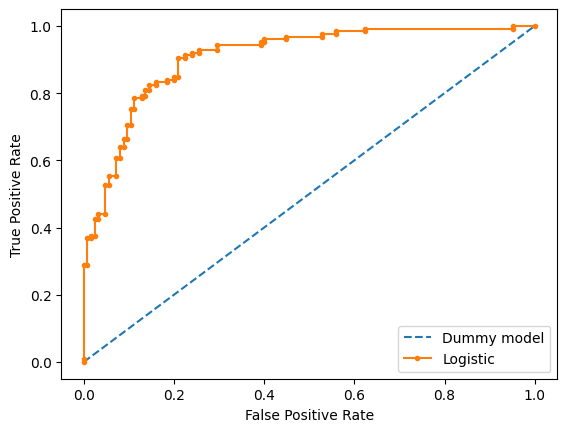

In [22]:
# plot the roc curve to the model
pyplot.plot(dummy_fpr,dummy_tpr,linestyle='--',label='Dummy model')
pyplot.plot(model_fpr,model_tpr,marker='.',label='Logistic')
# axis labels
pyplot.xlabel('False Positive Rate')
pyplot.ylabel('True Positive Rate')
# show the legend
pyplot.legend()
# show the plot
pyplot.show()

In [23]:
# How to select correct threshold?TPR MOST,FPR LEAST
model_fpr,model_tpr,thresholds=roc_curve(y_test,model_prob)

In [24]:
thresholds

array([           inf, 9.99408591e-01, 9.48789051e-01, 9.45875797e-01,
       9.35535228e-01, 9.34011458e-01, 9.28076959e-01, 9.26098222e-01,
       9.09462284e-01, 9.01743080e-01, 8.97971882e-01, 8.87913921e-01,
       8.55039135e-01, 8.50088338e-01, 8.45804170e-01, 8.32576905e-01,
       8.19647194e-01, 8.15943076e-01, 8.07941846e-01, 8.01595231e-01,
       7.72502908e-01, 7.72061776e-01, 7.18381195e-01, 7.16495666e-01,
       6.62185322e-01, 6.29275041e-01, 6.17835757e-01, 6.10039921e-01,
       5.96301960e-01, 5.88408407e-01, 5.69585444e-01, 5.42664587e-01,
       5.29164218e-01, 5.13611459e-01, 5.10245990e-01, 4.87974294e-01,
       4.84907445e-01, 4.56156711e-01, 4.47168571e-01, 4.26498394e-01,
       3.64869889e-01, 3.56886293e-01, 3.46033141e-01, 3.08051495e-01,
       3.01298121e-01, 2.85600699e-01, 2.85090339e-01, 2.18727039e-01,
       1.97022170e-01, 1.34038345e-01, 1.33315877e-01, 1.30519699e-01,
       1.27153287e-01, 1.04921781e-01, 1.04292580e-01, 7.04849255e-02,
      

## 🎯 What is the ROC Curve?

| Aspect | Explanation |
| :--- | :--- |
| **Full Form** | **Receiver Operating Characteristic Curve** |
| **What it does** | Plots **TPR (True Positive Rate)** vs **FPR (False Positive Rate)** at different classification thresholds |
| **Why it matters** | Shows the **trade-off** between catching positives and avoiding false alarms |
| **Perfect Model** | Curve hugs the **top-left corner** (TPR = 1, FPR = 0) |
| **Random Model** | Curve is a **diagonal line** (AUC = 0.5) |



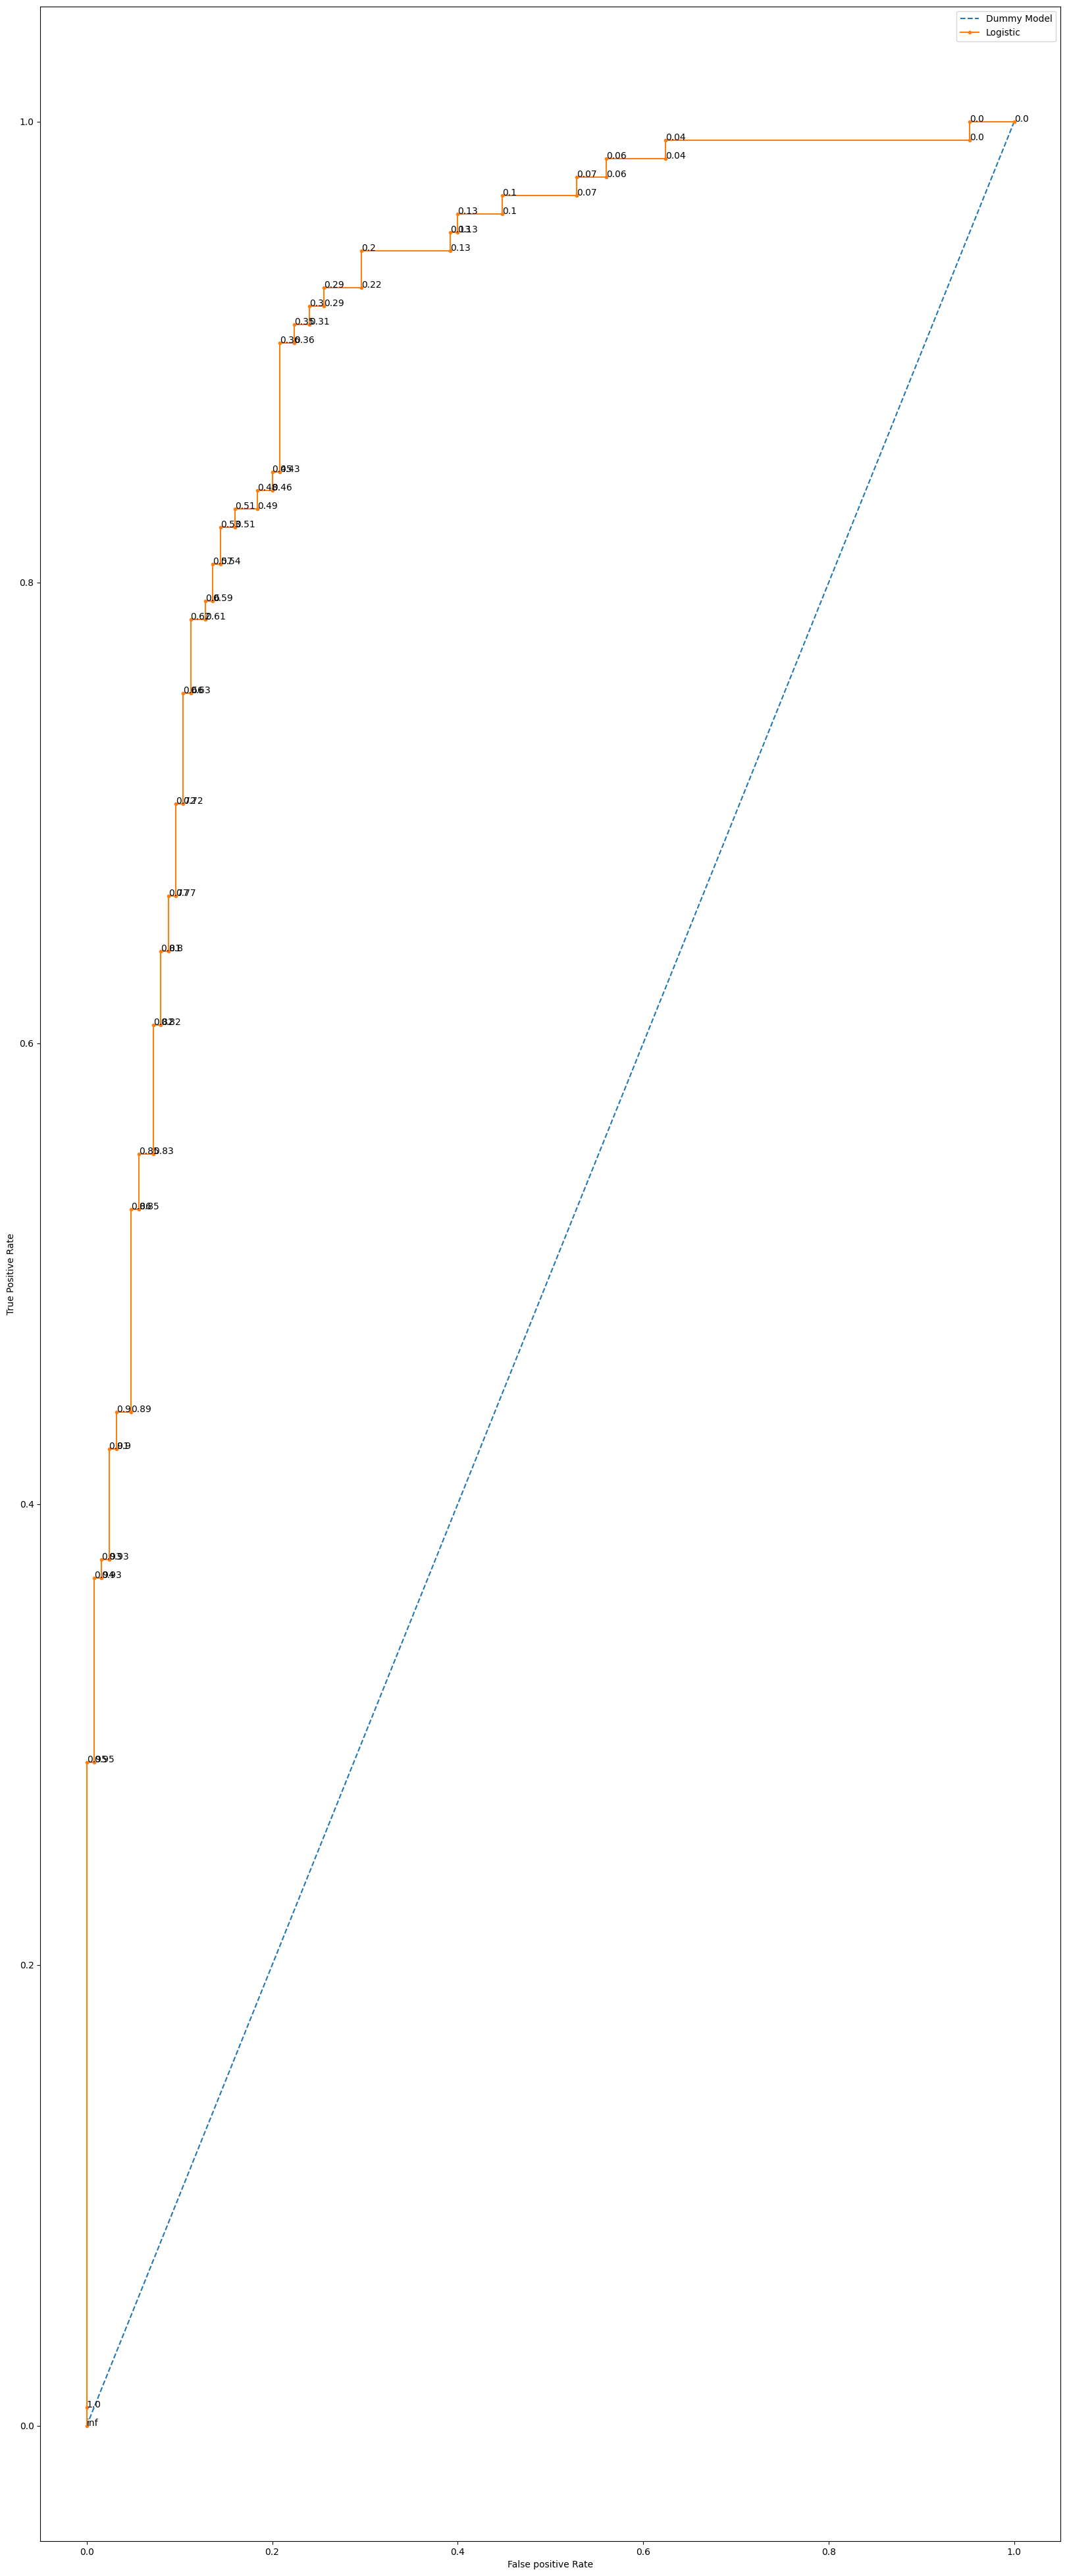

In [33]:
import matplotlib.pyplot as plt
# plot roc curve for this model
fig=plt.figure(figsize=(20,50))
import numpy as np
ax=fig.add_subplot(111)
ax.plot(dummy_fpr,dummy_tpr,linestyle='--',label='Dummy Model')
ax.plot(model_fpr,model_tpr,marker='.',label='Logistic')
for xyz in zip(model_fpr,model_tpr,thresholds):
  ax.annotate(f'{np.round(xyz[2],2)}',xy=(xyz[0],xyz[1]))
# axis labels
plt.xlabel('False positive Rate')
plt.ylabel('True Positive Rate')
# show the legend
plt.legend()
# show the plot
plt.show()

```python
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111)
```

---

## 🔍 What `111` Means

| Digit | Meaning |
| :--- | :--- |
| **1st digit (1)** | **Number of rows** in the subplot grid |
| **2nd digit (1)** | **Number of columns** in the subplot grid |
| **3rd digit (1)** | **Index** of the current subplot (starting from 1, left to right, top to bottom) |

> **`111` = 1 row, 1 column, 1st subplot = a single plot.**


MISTAKES NOT TO BE DONE:


You created ax but used plt.plot() for curves. plt.plot() creates a new figure, while ax.plot() plots on your existing subplot.

ax.plot() is called before ax=fig.add_subplot(111)